# Proyecto Final - Machine Learning 2  
## Clasificación de Imágenes - Intel Dataset
## Clasificación de Imágenes con Redes Neuronales Convolucionales (CNN)

## Descripción y contextualización del problema

En la actualidad, el análisis automático de imágenes se ha convertido en una herramienta fundamental en múltiples áreas como la vigilancia, la geografía, la conducción autónoma y los sistemas de recomendación. La capacidad de clasificar imágenes de manera automática permite extraer información relevante sin intervención humana, lo cual resulta clave en entornos con grandes volúmenes de datos.

En este contexto, el presente proyecto aborda el problema de clasificación de escenas naturales, donde el objetivo es identificar el tipo de entorno presente en una imagen. Específicamente, se trabaja con un conjunto de datos que contiene imágenes pertenecientes a seis categorías: buildings, forest, sea, street, glacier y mountain.

Desde el punto de vista del Machine Learning, este problema corresponde a una tarea de clasificación multiclase supervisada. Se dispone de un conjunto de imágenes etiquetadas, a partir del cual se busca entrenar un modelo capaz de aprender la relación entre las características visuales de las imágenes y sus respectivas clases.

Para resolver este problema, se emplean redes neuronales convolucionales (CNN), una arquitectura ampliamente utilizada en visión por computador debido a su capacidad para extraer automáticamente características relevantes como bordes, texturas y patrones espaciales.

Adicionalmente, se explora el uso de Transfer Learning mediante una arquitectura preentrenada, lo cual permite aprovechar conocimiento previo adquirido sobre grandes volúmenes de datos, mejorando el desempeño del modelo y reduciendo los tiempos de entrenamiento.

El objetivo principal es comparar diferentes enfoques de modelado y analizar su desempeño en términos de métricas de evaluación como accuracy, precision, recall y F1-score, así como mediante matrices de confusión que permitan identificar patrones de error entre clases.

# ------------------------------------------------------------------------
## 1. Librerías


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gdown
import zipfile
import tensorflow as tf
import random

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.optimizers import Adam

# ------------------------------------------------------------------------
## 2. Carga y preparación de los datos

En esta sección se realiza la descarga, descompresión y organización del conjunto de datos para su posterior uso en el entrenamiento de los modelos.




In [2]:
### Descarga del dataset

!pip install -q gdown

url = "https://drive.google.com/uc?id=1RzK_YQ9Enk_C3UFd4OeaaKodoXZe9iP0"

gdown.download(url, "dataset.zip", quiet=False)

# Descomprimir

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

# Definición de rutas

train_dir = "/content/seg_train/seg_train"
test_dir = "/content/seg_test/seg_test"

# Verificación del contenido

print(os.listdir(train_dir))

Downloading...
From (original): https://drive.google.com/uc?id=1RzK_YQ9Enk_C3UFd4OeaaKodoXZe9iP0
From (redirected): https://drive.google.com/uc?id=1RzK_YQ9Enk_C3UFd4OeaaKodoXZe9iP0&confirm=t&uuid=2245842f-b7f1-405f-b562-a3a0bfc371d4
To: /content/dataset.zip
100%|██████████| 254M/254M [00:01<00:00, 252MB/s]


['sea', 'forest', 'glacier', 'buildings', 'street', 'mountain']


# ------------------------------------------------------------------------
## 3. Funciones de evaluación y predicción

Con el fin de analizar el desempeño de los modelos y facilitar la interpretación de resultados, se implementaron dos funciones auxiliares: una para la evaluación cuantitativa de los modelos y otra para la predicción individual de imágenes.


### Función de evaluación de modelos

La función `evaluar_modelo` permite calcular métricas de desempeño y visualizar la matriz de confusión para un modelo entrenado.


In [3]:
def evaluar_modelo(modelo, nombre):
    val_generator.reset()

    pred = modelo.predict(val_generator)
    pred_classes = np.argmax(pred, axis=1)
    true_classes = val_generator.classes

    print(f"\n Reporte - {nombre}")
    print(classification_report(true_classes, pred_classes))

    cm = confusion_matrix(true_classes, pred_classes)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

### Función de predicción individual

La función `predecir_imagen` permite evaluar el comportamiento del modelo sobre una imagen específica.

In [4]:
def predecir_imagen(modelo, img_path, nombre_modelo):

    # Cargar imagen
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predicción
    pred = modelo.predict(img_array)
    class_index = np.argmax(pred)

    # Clases
    class_names = list(train_generator.class_indices.keys())

    # Mostrar imagen + predicción
    plt.imshow(img)
    plt.title(f"{nombre_modelo}: {class_names[class_index]}")
    plt.axis('off')
    plt.show()

    # Probabilidades
    print(f"\nProbabilidades - {nombre_modelo}")
    for i, prob in enumerate(pred[0]):
        print(f"{class_names[i]}: {prob:.4f}")

# ------------------------------------------------------------------------
## 4. Configuración del experimento

En esta sección se definen los parámetros principales utilizados durante el entrenamiento de los modelos.


In [5]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10

# ------------------------------------------------------------------------
## 5. Generadores de datos

Para la carga y preprocesamiento de las imágenes se utilizaron generadores de datos mediante la clase


In [6]:
# Preprocesamiento y Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Generador de entrenamiento
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

# Generador de validación
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


# ------------------------------------------------------------------------
## 6.  Descripción de la base de datos

El conjunto de datos utilizado en este proyecto corresponde a un dataset de clasificación de imágenes de escenas naturales, compuesto por un total aproximado de 14,000 imágenes distribuidas en seis categorías: buildings, forest, sea, street, glacier y mountain.

Las imágenes presentan variabilidad en términos de iluminación, perspectiva y contenido, lo cual representa un escenario realista para el entrenamiento de modelos de visión por computador.

El dataset se encuentra organizado en una estructura de carpetas, donde cada subdirectorio corresponde a una clase específica. Esta organización facilita su uso mediante generadores de datos, permitiendo la carga automática de imágenes y sus respectivas etiquetas.

Para el proceso de entrenamiento y validación, se utilizó una división interna del conjunto de datos, reservando el 80% de las imágenes para entrenamiento y el 20% para validación. Esta separación se realizó utilizando la funcionalidad `validation_split` de Keras.

Cada imagen fue redimensionada a un tamaño de 128x128 píxeles y normalizada escalando los valores de los píxeles al rango [0,1], con el fin de mejorar la estabilidad del entrenamiento.

Adicionalmente, se aplicaron técnicas de aumento de datos (data augmentation), incluyendo rotaciones, desplazamientos y reflejos horizontales, con el objetivo de incrementar la variabilidad del conjunto de entrenamiento y mejorar la capacidad de generalización de los modelos.

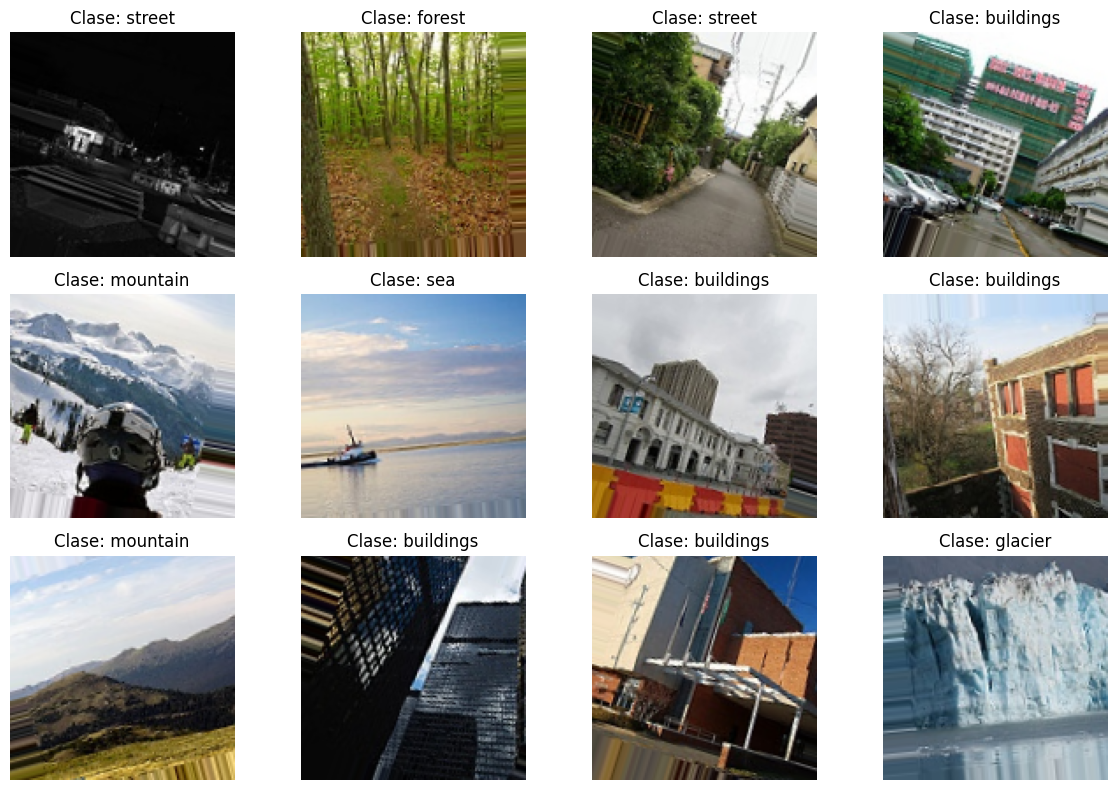

In [7]:
# Visualización de imágenes
images, labels = next(train_generator)

# Obtener nombres de clases
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(12,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i])

    # Convertir one-hot a índice
    class_index = np.argmax(labels[i])

    # Mostrar nombre de la clase
    plt.title(f"Clase: {class_names[class_index]}")

    plt.axis('off')

plt.tight_layout()
plt.show()

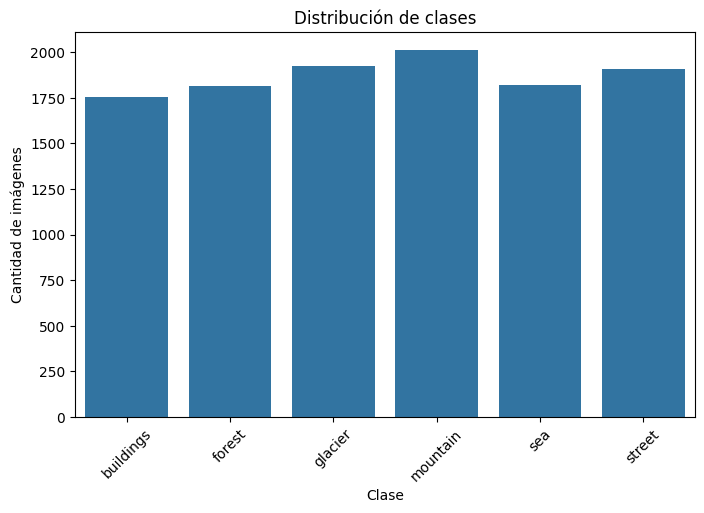

In [8]:
# Distribución de clases
class_counts = train_generator.classes
class_names = list(train_generator.class_indices.keys())

# Convertir a nombres
labels_names = [class_names[i] for i in class_counts]

# Contar
from collections import Counter
count_dict = Counter(labels_names)

# Graficar
plt.figure(figsize=(8,5))
sns.barplot(x=list(count_dict.keys()), y=list(count_dict.values()))
plt.title("Distribución de clases")
plt.xticks(rotation=45)
plt.ylabel("Cantidad de imágenes")
plt.xlabel("Clase")
plt.show()

A partir de la visualización y la distribución de clases, se observa que:

El dataset presenta una diversidad significativa de imágenes en cada categoría.
Las clases se encuentran relativamente balanceadas, lo cual es favorable para el entrenamiento de modelos de clasificación.
No se identifican sesgos evidentes hacia una clase específica.

Este análisis permite validar que el conjunto de datos es adecuado para el problema de clasificación planteado.

# ------------------------------------------------------------------------
## 7.  Diseño experimental

En este proyecto se desarrolló un proceso experimental estructurado para evaluar el desempeño de diferentes arquitecturas de redes neuronales en la tarea de clasificación de imágenes.

---

### Etapas del proceso

El desarrollo del experimento se realizó en las siguientes etapas:

A. **Carga de datos**  
   Se descargó y descomprimió el dataset, organizando las imágenes en carpetas por clase.

B. **Análisis exploratorio (EDA)**  
   Se visualizaron imágenes de ejemplo y se analizó la distribución de las clases para verificar la calidad y el balance del dataset.

C. **Preprocesamiento de datos**  
   Se normalizaron las imágenes (rescale) y se aplicaron técnicas de aumento de datos como rotación, desplazamiento y volteo horizontal.

D. **División de datos**  
   Se utilizó una división del 80% para entrenamiento y 20% para validación mediante `validation_split`.

E. **Definición de modelos**  
   Se implementaron tres modelos:
   - CNN básica
   - CNN mejorada (con BatchNorm y Dropout)
   - CNN mejorada (con BatchNorm y Dropout) + Residual
   - Transfer Learning (MobileNetV2)

F. **Entrenamiento**  
   Cada modelo fue entrenado utilizando los mismos datos y parámetros (batch size, epochs), aplicando Early Stopping para evitar sobreentrenamiento.

G. **Evaluación**  
   Se evaluó el desempeño de los modelos sobre el conjunto de validación.

---

### Cómo se realizaron las pruebas

Las pruebas se realizaron entrenando cada modelo de forma independiente bajo las mismas condiciones experimentales, lo cual permite realizar una comparación justa entre ellos.

Se utilizó el mismo conjunto de entrenamiento y validación, así como los mismos parámetros de configuración (tamaño de imagen, batch size y número de épocas).

Adicionalmente, se implementó Early Stopping para detener el entrenamiento cuando no se observaran mejoras en la pérdida de validación.

---

### Métricas de evaluación

Para evaluar el desempeño de los modelos se utilizaron las siguientes métricas:

- **Accuracy:** mide el porcentaje de predicciones correctas.
- **Precision:** indica la proporción de predicciones positivas correctas.
- **Recall:** mide la capacidad del modelo para identificar correctamente cada clase.
- **F1-score:** media armónica entre precision y recall.

Además, se utilizó la **matriz de confusión**, la cual permite analizar el comportamiento del modelo en cada clase y detectar errores de clasificación.

---

### Criterio de comparación

El criterio principal de comparación entre modelos fue la accuracy en el conjunto de validación, complementado con el análisis del F1-score y la matriz de confusión para evaluar el desempeño por clase.

Este enfoque permitió identificar la arquitectura más adecuada para el problema planteado.

# ------------------------------------------------------------------------
## 8.  Experimentos

En esta sección se presentan los experimentos realizados para evaluar el desempeño de diferentes arquitecturas de redes neuronales en la tarea de clasificación de imágenes.

Cada experimento consiste en el entrenamiento de un modelo bajo las mismas condiciones, seguido de su evaluación utilizando métricas estándar.


In [9]:
#  MODELO 1 - CNN BÁSICA (duración - aprox 10 min)

model1 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 199ms/step - accuracy: 0.6126 - loss: 0.9976 - val_accuracy: 0.7086 - val_loss: 0.7967
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 64s 183ms/step - accuracy: 0.7084 - loss: 0.7851 - val_accuracy: 0.7286 - val_loss: 0.7597
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 72s 206ms/step - accuracy: 0.7461 - loss: 0.6918 - val_accuracy: 0.7557 - val_loss: 0.6828
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 64s 183ms/step - accuracy: 0.7646 - loss: 0.6421 - val_accuracy: 0.7839 - val_loss: 0.5980
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 65s 186ms/step - accuracy: 0.7901 - loss: 0.5708 - val_accuracy: 0.8081 - val_loss: 0.5376
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 66s 188ms/step - accuracy: 0.8009 - loss: 0.5446 - val_accuracy: 0.7953 - val_loss: 0.5790
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - accuracy: 0.8035 - loss: 0.5409 - val_accuracy: 0.7939 - val_loss: 0.5610
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 66s 188ms/step - accuracy: 0.8170 - loss: 0

In [10]:
# MODELO 2 - CNN MEJORADA (duración - aprox 3 min)

model2 = models.Sequential([
    layers.Input(shape=(128,128,3)),

    # Bloque 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # Bloque 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # Bloque 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    # Dense
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(train_generator.num_classes, activation='softmax')
])

model2.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 92s 242ms/step - accuracy: 0.6538 - loss: 0.9264 - val_accuracy: 0.2910 - val_loss: 2.0579
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 69s 197ms/step - accuracy: 0.7452 - loss: 0.6924 - val_accuracy: 0.6195 - val_loss: 1.1676
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 68s 195ms/step - accuracy: 0.7763 - loss: 0.6229 - val_accuracy: 0.5150 - val_loss: 1.6766


In [11]:
# MODELO 3 - CNN MEJORADA + RESIDUAL (duración - aprox 3 min)

inputs = layers.Input(shape=(128,128,3))

# Bloque 1
x = layers.Conv2D(32, (3,3), padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(2,2)(x)

# Bloque 2 con residual
shortcut = x

x = layers.Conv2D(64, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

x = layers.Conv2D(64, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)

# Ajustar shortcut
shortcut = layers.Conv2D(64, (1,1), padding='same')(shortcut)

# Residual
x = layers.Add()([x, shortcut])
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(2,2)(x)

# Bloque 3
x = layers.Conv2D(128, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(2,2)(x)

# Clasificador
x = layers.Flatten()(x)

x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(train_generator.num_classes, activation='softmax')(x)

model3 = models.Model(inputs, outputs)

model3.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 88s 217ms/step - accuracy: 0.6671 - loss: 0.9023 - val_accuracy: 0.5160 - val_loss: 1.3599
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 68s 194ms/step - accuracy: 0.7635 - loss: 0.6608 - val_accuracy: 0.5585 - val_loss: 1.2745
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 67s 191ms/step - accuracy: 0.7773 - loss: 0.6016 - val_accuracy: 0.7065 - val_loss: 0.8362


In [12]:
# MODELO 4 - TRANSFER LEARNING (duración - aprox 10 min)

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(train_generator.num_classes, activation='softmax')(x)

model4 = models.Model(inputs=base_model.input, outputs=output)

model4.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history4 = model4.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 114s 276ms/step - accuracy: 0.8481 - loss: 0.4124 - val_accuracy: 0.8841 - val_loss: 0.3271
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 65s 185ms/step - accuracy: 0.8843 - loss: 0.3165 - val_accuracy: 0.8877 - val_loss: 0.3206
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 64s 181ms/step - accuracy: 0.8922 - loss: 0.2876 - val_accuracy: 0.8834 - val_loss: 0.3044
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 63s 178ms/step - accuracy: 0.8982 - loss: 0.2688 - val_accuracy: 0.8927 - val_loss: 0.2892
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 63s 180ms/step - accuracy: 0.9050 - loss: 0.2577 - val_accuracy: 0.8884 - val_loss: 0.3083
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 201ms/step - accuracy: 0.9090 - loss: 0.2393 - val_accuracy: 0.8837 - val_loss: 0.3076
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 64s 182ms/step - accuracy: 0.9106 - loss: 0.2359 - val_accuracy: 0.9005 - val_loss: 0.2874
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 179ms/step - accuracy: 0.9116 - loss: 

Durante el entrenamiento de algunos modelos se observó que el proceso se detuvo antes de completar el número máximo de épocas definido.

Esto se debe a la implementación de la técnica de Early Stopping, la cual detiene el entrenamiento cuando la métrica de validación (val_loss) deja de mejorar durante un número determinado de épocas (patience=3).

En este caso, el modelo alcanzó rápidamente su mejor desempeño en las primeras épocas, por lo que continuar el entrenamiento no generaba mejoras adicionales. Como resultado, el entrenamiento se detuvo anticipadamente.

Este comportamiento indica una rápida convergencia del modelo y contribuye a evitar el sobreajuste.

## Evaluar

## Evaluación y predicción de los modelos

Con el fin de analizar el desempeño de los modelos entrenados, se realizaron dos tipos de pruebas:

1. Evaluación global mediante métricas de clasificación
2. Predicción individual sobre imágenes específicas

## 1. Evaluación global mediante métricas de clasificación

88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 198ms/step

 Reporte - CNN Básica
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       438
           1       0.94      0.94      0.94       454
           2       0.81      0.74      0.77       480
           3       0.75      0.80      0.77       502
           4       0.80      0.81      0.81       454
           5       0.83      0.83      0.83       476

    accuracy                           0.82      2804
   macro avg       0.82      0.82      0.82      2804
weighted avg       0.82      0.82      0.82      2804



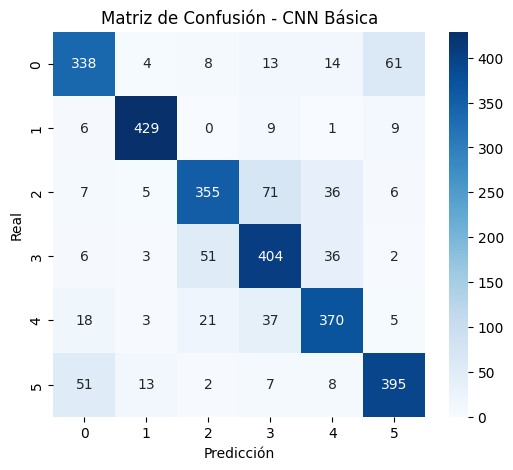

88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step

 Reporte - CNN Mejorada
              precision    recall  f1-score   support

           0       0.82      0.06      0.11       438
           1       1.00      0.00      0.00       454
           2       0.35      0.28      0.31       480
           3       0.75      0.03      0.06       502
           4       0.22      0.95      0.36       454
           5       0.48      0.45      0.46       476

    accuracy                           0.29      2804
   macro avg       0.60      0.29      0.22      2804
weighted avg       0.60      0.29      0.22      2804



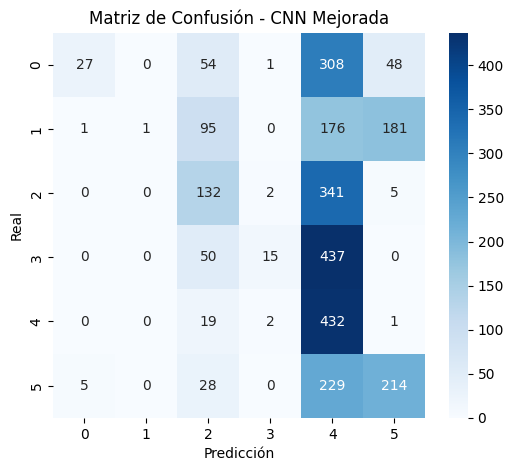

88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step

 Reporte - CNN Mejorada + Residual
              precision    recall  f1-score   support

           0       0.41      0.72      0.52       438
           1       1.00      0.09      0.16       454
           2       0.47      0.54      0.50       480
           3       0.74      0.40      0.52       502
           4       0.50      0.76      0.60       454
           5       0.55      0.57      0.56       476

    accuracy                           0.51      2804
   macro avg       0.61      0.51      0.48      2804
weighted avg       0.61      0.51      0.48      2804



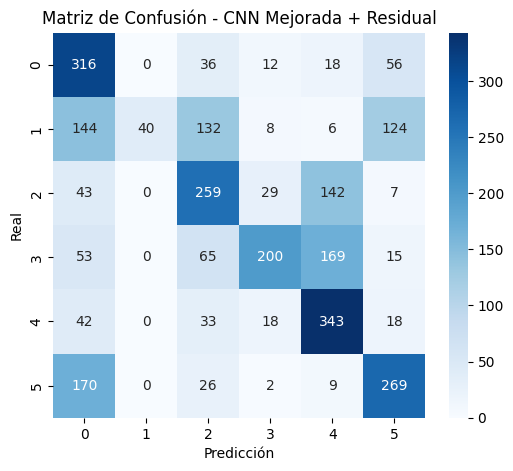

88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 195ms/step

 Reporte - Transfer Learning
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       438
           1       0.98      0.97      0.97       454
           2       0.85      0.78      0.81       480
           3       0.80      0.87      0.83       502
           4       0.91      0.88      0.90       454
           5       0.90      0.94      0.92       476

    accuracy                           0.89      2804
   macro avg       0.89      0.89      0.89      2804
weighted avg       0.89      0.89      0.89      2804



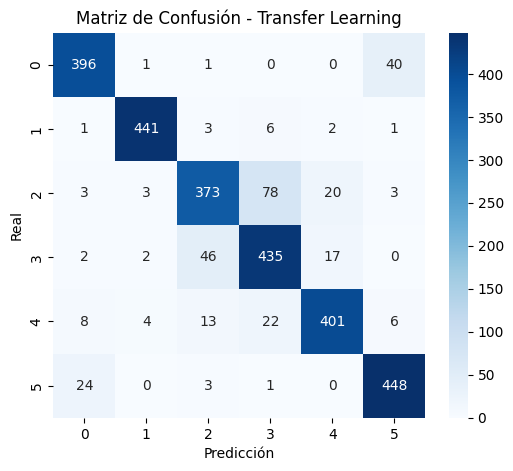

In [13]:
evaluar_modelo(model1, "CNN Básica")
evaluar_modelo(model2, "CNN Mejorada")
evaluar_modelo(model3, "CNN Mejorada + Residual")
evaluar_modelo(model4, "Transfer Learning")

### Matriz de confusión – CNN Mejorada

La matriz de confusión evidencia claramente un comportamiento inadecuado del modelo.

Se observa que la mayoría de las predicciones se concentran en la **clase 4**, independientemente de la clase real.

---

### Observaciones clave

- La columna correspondiente a la clase 4 contiene valores muy altos en todas las filas.
- Esto indica que el modelo está clasificando la mayoría de las imágenes como clase 4.
- Solo en pocos casos se logran predicciones correctas en otras clases.

---

### Interpretación

Este patrón confirma que el modelo presenta un **colapso hacia una clase dominante**, donde predice casi exclusivamente una única clase.

Como consecuencia:

- El **recall de la clase 4 es muy alto**
- El **recall de las demás clases es cercano a cero**
- La **accuracy global es baja (22%)**

---

### Conclusión

El modelo no logró aprender una representación adecuada de las distintas clases, optando por una solución trivial que minimiza la pérdida prediciendo siempre la misma categoría.

Este comportamiento refleja problemas de entrenamiento y falta de generalización.

In [14]:
results = pd.DataFrame({
    'Modelo': ['CNN Básica', 'CNN Mejorada', 'CNN Mejorada + Residual', 'Transfer Learning'],
    'Accuracy': [max(history1.history['val_accuracy']),
                 max(history2.history['val_accuracy']),
                 max(history3.history['val_accuracy']),
                 max(history4.history['val_accuracy'])]
})

print(results)

                    Modelo  Accuracy
0               CNN Básica  0.808131
1             CNN Mejorada  0.619472
2  CNN Mejorada + Residual  0.706491
3        Transfer Learning  0.900499


## 2. Predicción individual sobre imágenes específicas

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step


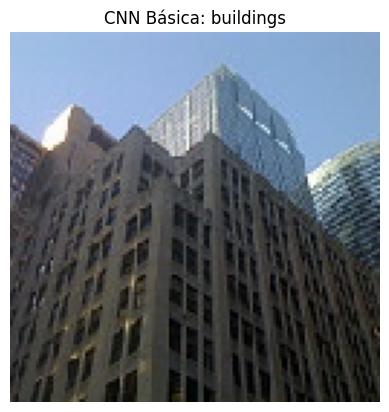


Probabilidades - CNN Básica
buildings: 0.9377
forest: 0.0062
glacier: 0.0021
mountain: 0.0392
sea: 0.0016
street: 0.0132
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 909ms/step


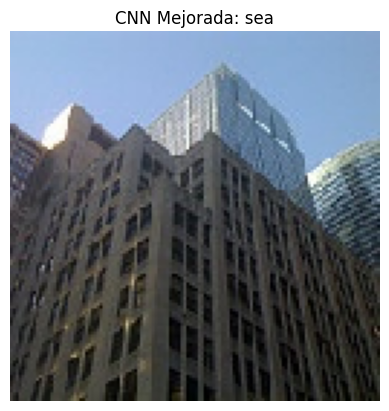


Probabilidades - CNN Mejorada
buildings: 0.0803
forest: 0.0017
glacier: 0.2516
mountain: 0.2424
sea: 0.3226
street: 0.1014


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


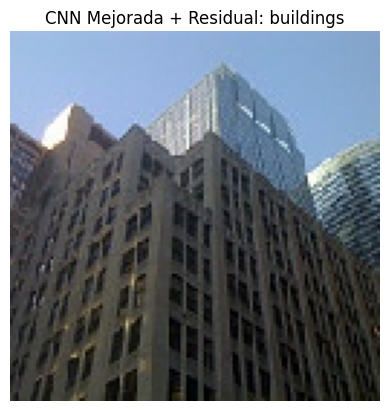


Probabilidades - CNN Mejorada + Residual
buildings: 0.4241
forest: 0.0046
glacier: 0.0794
mountain: 0.4224
sea: 0.0295
street: 0.0400


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


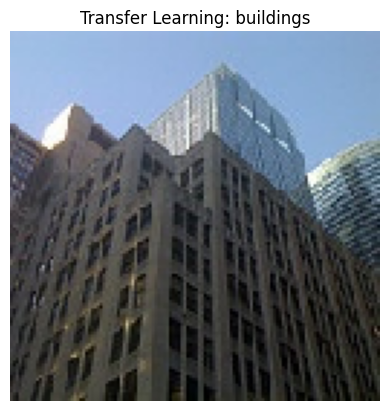


Probabilidades - Transfer Learning
buildings: 1.0000
forest: 0.0000
glacier: 0.0000
mountain: 0.0000
sea: 0.0000
street: 0.0000


In [15]:
img_path = train_generator.filepaths[0]  # Se puede modifcar a cualquier imagen

predecir_imagen(model1, img_path, "CNN Básica")
predecir_imagen(model2, img_path, "CNN Mejorada")
predecir_imagen(model3, img_path, "CNN Mejorada + Residual")
predecir_imagen(model4, img_path, "Transfer Learning")

# ------------------------------------------------------------------------
## 9. Conclusiones del estudio

A partir de los experimentos realizados, se comparó el desempeño de tres modelos de clasificación de imágenes: una CNN básica, una CNN mejorada, una CNN mejorada con residual y un modelo basado en Transfer Learning.

---

### Análisis de resultados

El modelo de **Transfer Learning** obtuvo el mejor desempeño, alcanzando una accuracy cercana al 90%. Este resultado demuestra la efectividad de utilizar modelos preentrenados como extractores de características, especialmente en problemas de visión por computador.

La **CNN básica** presentó un desempeño sólido (80%), logrando capturar patrones relevantes a pesar de su simplicidad. Esto la convierte en una buena línea base para comparación.

Por otro lado, la **CNN mejorada**, a pesar de incorporar técnicas como Batch Normalization y Dropout, obtuvo un desempeño inferior (62%). Esto evidencia que aumentar la complejidad del modelo no garantiza mejores resultados si no se ajustan adecuadamente los hiperparámetros y el proceso de entrenamiento.

Por ultimo, **CNN mejorada con residual** si logra mejores metricas y predicciones, obtuvo un deseméño de 70%.
---

### Mejores configuraciones

Se identificaron como configuraciones más efectivas:

- Uso de **Transfer Learning (MobileNetV2)**
- Congelación de capas preentrenadas (`trainable = False`)
- Uso de **GlobalAveragePooling** en lugar de Flatten
- Aplicación de **Early Stopping** para evitar sobreajuste
- Normalización de imágenes y data augmentation

---

### Observaciones clave

- Los modelos más simples pueden ofrecer buen rendimiento con menor costo computacional.
- La correcta configuración del entrenamiento es tan importante como la arquitectura.
- El Transfer Learning permite obtener resultados superiores con menor esfuerzo de entrenamiento.

---

### Conclusión general

El uso de modelos preentrenados representa la mejor estrategia para este tipo de problema, logrando un equilibrio óptimo entre desempeño y eficiencia. Este enfoque permite aprovechar conocimiento previo y mejorar significativamente la capacidad de generalización del modelo.